##Problem 1:

Loading Data:

In [1]:
import copy
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
from torchvision.models import resnet18

SEED = 42
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 100
IMAGE_SIZE = 32
NUM_WORKERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


CIFAR Loading:

In [2]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD)
])

full_train_augmented = torchvision.datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

full_train_unaugmented = torchvision.datasets.CIFAR100(
    root="./data",
    train=True,
    download=False,
    transform=test_transform
)

test_dataset = torchvision.datasets.CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(full_train_augmented), generator=generator).tolist()

train_indices = indices[:45000]
validation_indices = indices[45000:]

train_dataset = Subset(full_train_augmented, train_indices)
validation_dataset = Subset(full_train_unaugmented, validation_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Test samples:", len(test_dataset))
print("Classes:", len(full_train_augmented.classes))

100%|██████████| 169M/169M [32:12<00:00, 87.5kB/s]


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Classes: 100


Architecture:

In [3]:
class PatchEmbedding(nn.Module):
    def __init__(
        self,
        image_size,
        patch_size,
        embedding_dimension
    ):
        super().__init__()

        if image_size % patch_size != 0:
            raise ValueError("Image size must be divisible by patch size.")

        self.number_of_patches = (image_size // patch_size) ** 2

        self.projection = nn.Conv2d(
            in_channels=3,
            out_channels=embedding_dimension,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.projection(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)

        return x


class MultiHeadSelfAttention(nn.Module):
    def __init__(
        self,
        embedding_dimension,
        number_of_heads,
        dropout
    ):
        super().__init__()

        if embedding_dimension % number_of_heads != 0:
            raise ValueError("Embedding dimension must be divisible by heads.")

        self.number_of_heads = number_of_heads

        self.head_dimension = (embedding_dimension // number_of_heads)

        self.scale = self.head_dimension ** -0.5

        self.qkv = nn.Linear(embedding_dimension, embedding_dimension * 3)

        self.attention_dropout = nn.Dropout(dropout)

        self.output_projection = nn.Linear(embedding_dimension, embedding_dimension)

        self.output_dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, sequence_length, embedding_dimension = (x.shape)

        qkv = self.qkv(x)

        qkv = qkv.reshape(
            batch_size,
            sequence_length,
            3,
            self.number_of_heads,
            self.head_dimension
        )

        qkv = qkv.permute(
            2,
            0,
            3,
            1,
            4
        )

        query, key, value = (
            qkv[0],
            qkv[1],
            qkv[2]
        )

        attention_scores = (query @ key.transpose(-2, -1)) * self.scale

        attention_weights = torch.softmax(attention_scores, dim=-1)

        attention_weights = self.attention_dropout(attention_weights)

        output = attention_weights @ value

        output = output.transpose(1,2)

        output = output.reshape(batch_size,sequence_length,embedding_dimension)

        output = self.output_projection(output)

        output = self.output_dropout(output)

        return output


class TransformerMLP(nn.Module):
    def __init__(
        self,
        embedding_dimension,
        mlp_hidden_dimension,
        dropout
    ):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(
                embedding_dimension,
                mlp_hidden_dimension
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                mlp_hidden_dimension,
                embedding_dimension
            ),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.layers(x)


class TransformerEncoderBlock(nn.Module):
    def __init__(
        self,
        embedding_dimension,
        number_of_heads,
        mlp_hidden_dimension,
        dropout
    ):
        super().__init__()

        self.normalization1 = nn.LayerNorm(embedding_dimension)

        self.attention = MultiHeadSelfAttention(
            embedding_dimension,
            number_of_heads,
            dropout
        )

        self.normalization2 = nn.LayerNorm(embedding_dimension)

        self.mlp = TransformerMLP(
            embedding_dimension,
            mlp_hidden_dimension,
            dropout
        )

    def forward(self, x):
        x = x + self.attention(self.normalization1(x))

        x = x + self.mlp(self.normalization2(x))

        return x


class VisionTransformer(nn.Module):
    def __init__(
        self,
        image_size=32,
        patch_size=4,
        embedding_dimension=256,
        number_of_blocks=4,
        number_of_heads=4,
        mlp_hidden_dimension=1024,
        number_of_classes=100,
        dropout=0.1
    ):
        super().__init__()

        self.patch_embedding = PatchEmbedding(
            image_size,
            patch_size,
            embedding_dimension
        )

        number_of_patches = (
            self.patch_embedding.number_of_patches
        )

        self.class_token = nn.Parameter(
            torch.zeros(
                1,
                1,
                embedding_dimension
            )
        )

        self.position_embedding = nn.Parameter(
            torch.zeros(
                1,
                number_of_patches + 1,
                embedding_dimension
            )
        )

        self.embedding_dropout = nn.Dropout(
            dropout
        )

        self.encoder_blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embedding_dimension,
                number_of_heads,
                mlp_hidden_dimension,
                dropout
            )
            for _ in range(number_of_blocks)
        ])

        self.final_normalization = nn.LayerNorm(embedding_dimension)

        self.classification_head = nn.Linear(embedding_dimension,number_of_classes)

        self.initialize_parameters()

    def initialize_parameters(self):
        nn.init.trunc_normal_(
            self.class_token,
            std=0.02
        )

        nn.init.trunc_normal_(
            self.position_embedding,
            std=0.02
        )

        self.apply(
            self.initialize_layer
        )

    @staticmethod
    def initialize_layer(layer):
        if isinstance(layer, nn.Linear):
            nn.init.trunc_normal_(layer.weight, std=0.02)

            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

        elif isinstance(layer, nn.LayerNorm):
            nn.init.ones_(layer.weight)

            nn.init.zeros_(layer.bias)

    def forward(self, x):
        batch_size = x.shape[0]

        x = self.patch_embedding(x)

        class_tokens = self.class_token.expand(batch_size, -1,-1)

        x = torch.cat((class_tokens, x),dim=1)

        x = x + self.position_embedding

        x = self.embedding_dropout(x)

        for encoder_block in self.encoder_blocks:
            x = encoder_block(x)

        x = self.final_normalization(x)

        x = x[:, 0]

        x = self.classification_head(x)

        return x

Res-net18 Model:

In [4]:
def create_resnet18():
    model = resnet18(weights=None)

    model.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

    model.maxpool = nn.Identity()

    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    return model


def count_parameters(model):
    return sum(parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def calculate_vit_parameters(
    image_size,
    patch_size,
    embedding_dimension,
    number_of_blocks,
    mlp_hidden_dimension,
    number_of_classes
):
    number_of_patches = (image_size // patch_size) ** 2

    sequence_length = (number_of_patches + 1)

    patch_parameters = (embedding_dimension * 3 * patch_size * patch_size + embedding_dimension)

    class_token_parameters = (embedding_dimension)

    position_parameters = (sequence_length * embedding_dimension)

    normalization_parameters = (4 * embedding_dimension)

    qkv_parameters = (3 * embedding_dimension* embedding_dimension+ 3 * embedding_dimension)

    attention_output_parameters = (
        embedding_dimension
        * embedding_dimension
        + embedding_dimension
    )

    mlp_parameters = (
        embedding_dimension
        * mlp_hidden_dimension
        + mlp_hidden_dimension
        + mlp_hidden_dimension
        * embedding_dimension
        + embedding_dimension
    )

    block_parameters = (
        normalization_parameters
        + qkv_parameters
        + attention_output_parameters
        + mlp_parameters
    )

    final_normalization_parameters = (2 * embedding_dimension)

    classification_parameters = (
        embedding_dimension
        * number_of_classes
        + number_of_classes
    )

    total_parameters = (
        patch_parameters
        + class_token_parameters
        + position_parameters
        + number_of_blocks
        * block_parameters
        + final_normalization_parameters
        + classification_parameters
    )

    return total_parameters


def calculate_vit_flops(
    image_size,
    patch_size,
    embedding_dimension,
    number_of_blocks,
    mlp_hidden_dimension,
    number_of_classes
):
    number_of_patches = (image_size // patch_size) ** 2

    sequence_length = (number_of_patches + 1)

    patch_flops = (2 * number_of_patches * embedding_dimension * 3 * patch_size * patch_size)

    qkv_flops = (2 * sequence_length * embedding_dimension * 3 * embedding_dimension)

    attention_score_flops = (2 * sequence_length * sequence_length * embedding_dimension)

    attention_value_flops = (2 * sequence_length * sequence_length * embedding_dimension)

    attention_projection_flops = (2 * sequence_length * embedding_dimension * embedding_dimension)

    mlp_flops = (2 * sequence_length * embedding_dimension * mlp_hidden_dimension + 2 * sequence_length * mlp_hidden_dimension * embedding_dimension
    )

    block_flops = (
        qkv_flops
        + attention_score_flops
        + attention_value_flops
        + attention_projection_flops
        + mlp_flops
    )

    classification_flops = (2 * embedding_dimension * number_of_classes)

    total_flops = (
        patch_flops
        + number_of_blocks
        * block_flops
        + classification_flops
    )

    return total_flops


def profile_model_flops(model):
    profiler_model = copy.deepcopy(model).to(DEVICE)

    profiler_model.eval()

    sample_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)

    activities = [torch.profiler.ProfilerActivity.CPU]

    if DEVICE.type == "cuda":
        activities.append(torch.profiler.ProfilerActivity.CUDA)

    with torch.no_grad():
        with torch.profiler.profile(
            activities=activities,
            record_shapes=True,
            with_flops=True) as profiler:
            profiler_model(sample_input)

    total_flops = sum(
        event.flops
        for event in profiler.key_averages()
        if event.flops is not None
    )

    del profiler_model

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return total_flops

Training:

In [5]:
def evaluate_model(
    model,
    data_loader,
    criterion
):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(DEVICE, non_blocking=True)

            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs,labels)

            batch_size = labels.size(0)

            total_loss += (loss.item() * batch_size)

            total_correct += (outputs.argmax(dim=1) == labels).sum().item()

            total_samples += (batch_size)

    average_loss = (total_loss / total_samples)

    accuracy = (100 * total_correct / total_samples)

    return average_loss, accuracy


def train_model(model, model_name):
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {
        "training_loss": [],
        "training_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": [],
        "epoch_time": []
    }

    best_validation_accuracy = 0.0
    best_model_state = None

    total_start_time = (time.perf_counter())

    for epoch in range(EPOCHS):
        model.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        epoch_start_time = (time.perf_counter())

        for images, labels in train_loader:
            images = images.to(DEVICE, non_blocking=True)

            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            batch_size = labels.size(0)

            total_loss += (loss.item() * batch_size)

            total_correct += (outputs.argmax(dim=1) == labels).sum().item()

            total_samples += (batch_size)

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        epoch_time = (time.perf_counter()- epoch_start_time)

        training_loss = (total_loss / total_samples)

        training_accuracy = (100 * total_correct / total_samples)

        validation_loss, validation_accuracy = (evaluate_model(model, validation_loader, criterion))

        history["training_loss"].append(training_loss)

        history["training_accuracy"].append(training_accuracy)

        history["validation_loss"].append(validation_loss)

        history["validation_accuracy"].append(validation_accuracy)

        history["epoch_time"].append(epoch_time)

        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = (validation_accuracy)

            best_model_state = copy.deepcopy(model.state_dict())

        print(
            f"{model_name} | "
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"Train Loss: {training_loss:.4f} | "
            f"Train Acc: {training_accuracy:.2f}% | "
            f"Val Loss: {validation_loss:.4f} | "
            f"Val Acc: {validation_accuracy:.2f}% | "
            f"Time: {epoch_time:.2f} sec"
        )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    total_training_time = (time.perf_counter()- total_start_time)

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    test_loss, test_accuracy = (
        evaluate_model(model, test_loader, criterion))

    average_epoch_time = float(
        np.mean(history["epoch_time"])
    )

    print("-" * 80)

    print(
        f"{model_name} best validation accuracy: "
        f"{best_validation_accuracy:.2f}%"
    )

    print(
        f"{model_name} test accuracy: "
        f"{test_accuracy:.2f}%"
    )

    print(
        f"{model_name} average epoch time: "
        f"{average_epoch_time:.2f} seconds"
    )

    print("-" * 80)

    return {
        "model": model,
        "history": history,
        "best_validation_accuracy": best_validation_accuracy,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "average_epoch_time": average_epoch_time,
        "total_training_time": total_training_time
    }

Running Experiment:

In [ ]:
vit_configurations = [
    {
        "name": "ViT-P4-D256-B4-H4",
        "patch_size": 4,
        "embedding_dimension": 256,
        "number_of_blocks": 4,
        "number_of_heads": 4
    },
    {
        "name": "ViT-P8-D256-B4-H8",
        "patch_size": 8,
        "embedding_dimension": 256,
        "number_of_blocks": 4,
        "number_of_heads": 8
    },
    {
        "name": "ViT-P4-D512-B8-H8",
        "patch_size": 4,
        "embedding_dimension": 512,
        "number_of_blocks": 8,
        "number_of_heads": 8
    },
    {
        "name": "ViT-P8-D512-B8-H4",
        "patch_size": 8,
        "embedding_dimension": 512,
        "number_of_blocks": 8,
        "number_of_heads": 4
    }
]

results = []
histories = {}

for configuration in vit_configurations:
    mlp_hidden_dimension = (4* configuration["embedding_dimension"])

    model = VisionTransformer(
        image_size=IMAGE_SIZE,
        patch_size=configuration["patch_size"],
        embedding_dimension=configuration["embedding_dimension"],
        number_of_blocks=configuration["number_of_blocks"],
        number_of_heads=configuration["number_of_heads"],
        mlp_hidden_dimension=mlp_hidden_dimension,
        number_of_classes=NUM_CLASSES
    )

    actual_parameters = count_parameters(model)

    theoretical_parameters = calculate_vit_parameters(image_size=IMAGE_SIZE,
        patch_size=configuration["patch_size"],
        embedding_dimension=configuration["embedding_dimension"],
        number_of_blocks=configuration["number_of_blocks"],
        mlp_hidden_dimension=mlp_hidden_dimension,
        number_of_classes=NUM_CLASSES
    )

    estimated_flops = calculate_vit_flops(image_size=IMAGE_SIZE,
        patch_size=configuration["patch_size"],
        embedding_dimension=configuration["embedding_dimension"],
        number_of_blocks=configuration["number_of_blocks"],
        mlp_hidden_dimension=mlp_hidden_dimension,
        number_of_classes=NUM_CLASSES
    )

    output = train_model(model, configuration["name"])

    number_of_patches = (IMAGE_SIZE // configuration["patch_size"]) ** 2

    results.append({
        "Model": configuration["name"],
        "Patch Size": configuration["patch_size"],
        "Embedding Dimension": configuration[
            "embedding_dimension"
        ],
        "Blocks": configuration[
            "number_of_blocks"
        ],
        "Heads": configuration[
            "number_of_heads"
        ],
        "MLP Dimension": mlp_hidden_dimension,
        "Sequence Length": number_of_patches + 1,
        "Actual Parameters": actual_parameters,
        "Theoretical Parameters": theoretical_parameters,
        "Estimated FLOPs": estimated_flops,
        "Best Validation Accuracy (%)": output[
            "best_validation_accuracy"
        ],
        "Test Accuracy (%)": output[
            "test_accuracy"
        ],
        "Average Epoch Time (sec)": output[
            "average_epoch_time"
        ],
        "Total Training Time (sec)": output[
            "total_training_time"
        ]
    })

    histories[configuration["name"]] = output["history"]

    output["model"].to("cpu")

    del model
    del output

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


resnet_model = create_resnet18()

resnet_parameters = count_parameters(
    resnet_model
)

resnet_flops = profile_model_flops(
    resnet_model
)

resnet_output = train_model(resnet_model, "ResNet-18")

results.append({
    "Model": "ResNet-18",
    "Patch Size": "N/A",
    "Embedding Dimension": "N/A",
    "Blocks": "N/A",
    "Heads": "N/A",
    "MLP Dimension": "N/A",
    "Sequence Length": "N/A",
    "Actual Parameters": resnet_parameters,
    "Theoretical Parameters": resnet_parameters,
    "Estimated FLOPs": resnet_flops,
    "Best Validation Accuracy (%)": resnet_output[
        "best_validation_accuracy"
    ],
    "Test Accuracy (%)": resnet_output[
        "test_accuracy"
    ],
    "Average Epoch Time (sec)": resnet_output[
        "average_epoch_time"
    ],
    "Total Training Time (sec)": resnet_output[
        "total_training_time"
    ]
})

histories["ResNet-18"] = (resnet_output["history"])

resnet_output["model"].to("cpu")

del resnet_model
del resnet_output

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print("Completed experiments:", len(results))
print("Stored histories:", list(histories.keys()))

Results:

,Model,Patch Size,Embedding Dimension,Blocks,Heads,Best Validation Accuracy (%),Test Accuracy (%),Average Epoch Time (sec),Total Training Time (sec),Actual Parameters (Millions),Theoretical Parameters (Millions),Estimated FLOPs (Millions)
0,ViT-P4-D256-B4-H4,4,256,4,4,25.28,25.34,28.687,301.139,3.215,3.215,427.874
1,ViT-P8-D256-B4-H8,8,256,4,8,19.16,18.56,22.847,243.227,3.239,3.239,109.763
2,ViT-P4-D512-B8-H8,4,512,8,8,8.86,8.54,160.707,1667.405,25.330,25.330,3344.028
3,ViT-P8-D512-B8-H4,8,512,8,4,4.46,4.36,47.867,497.873,25.379,25.379,863.621
4,ResNet-18,N/A,N/A,N/A,N/A,59.24,59.97,43.217,449.244,11.220,11.220,1110.938


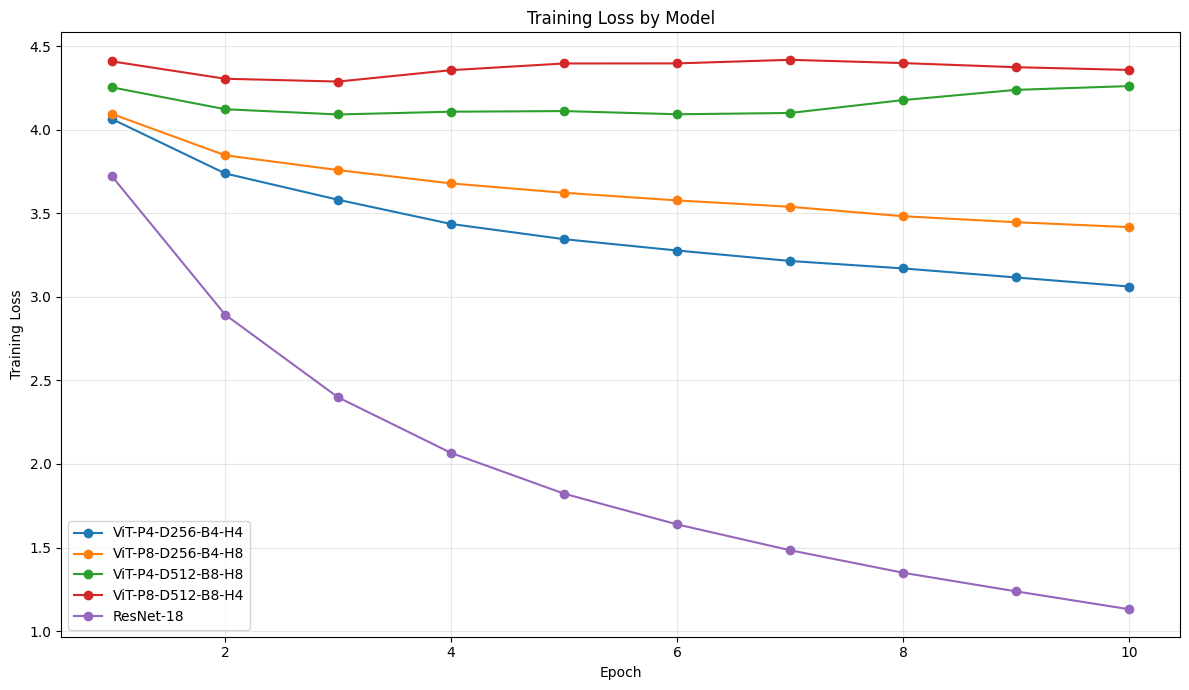

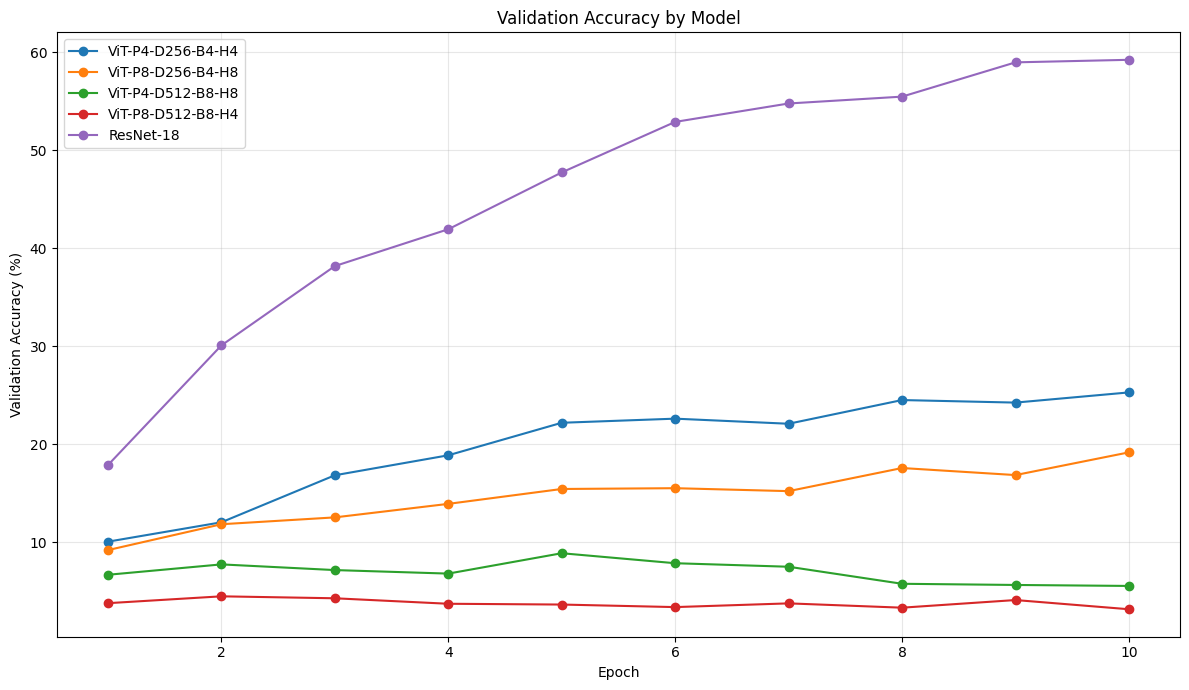

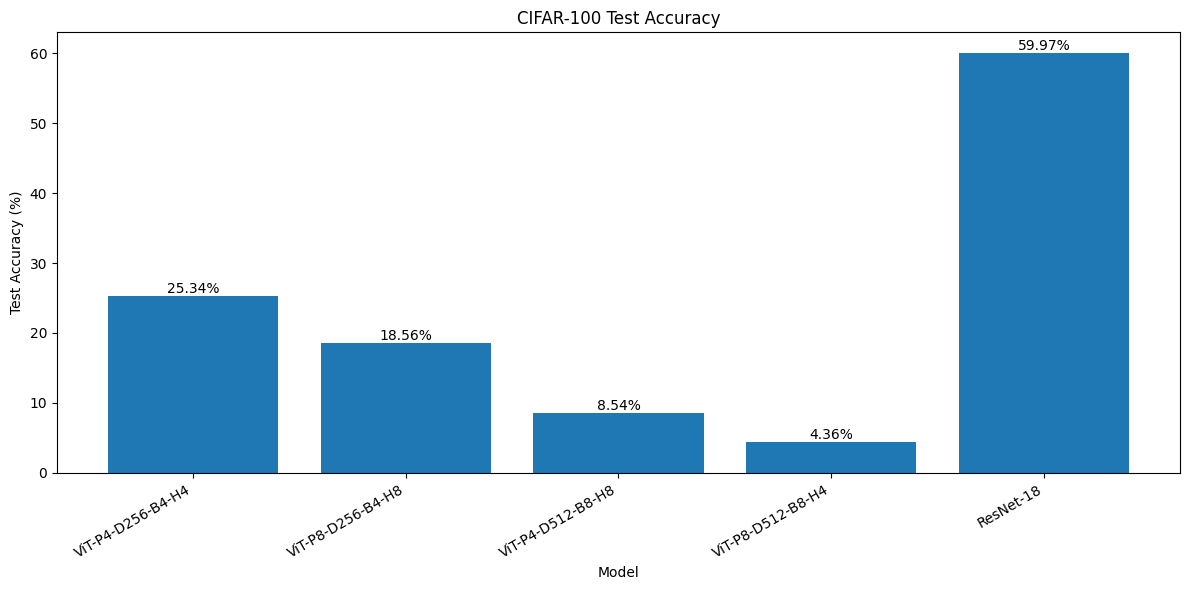

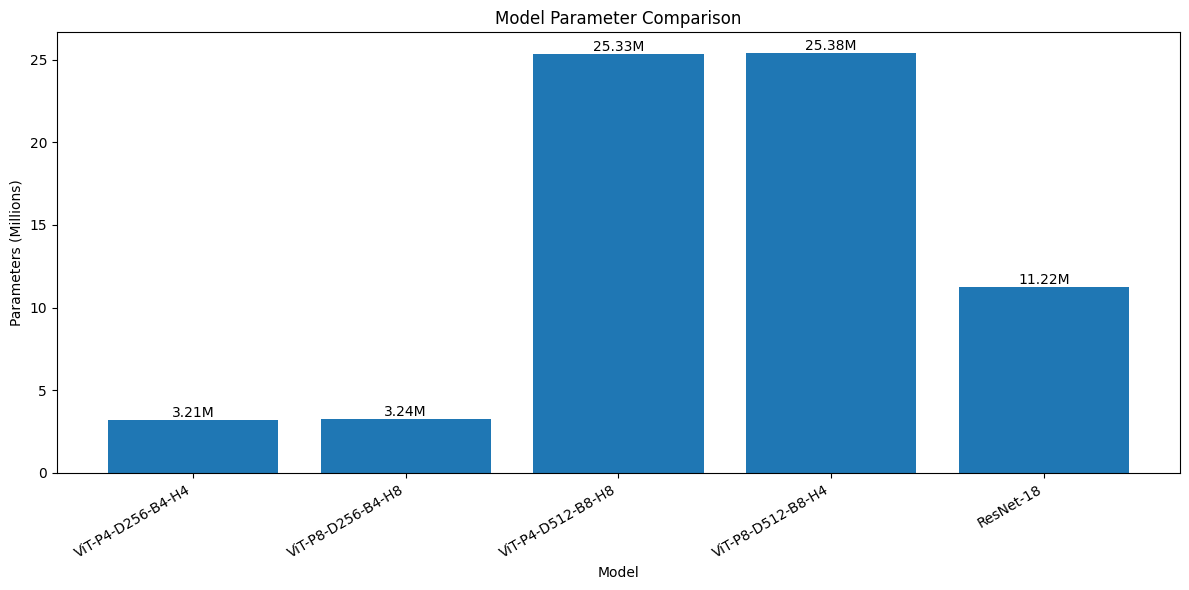

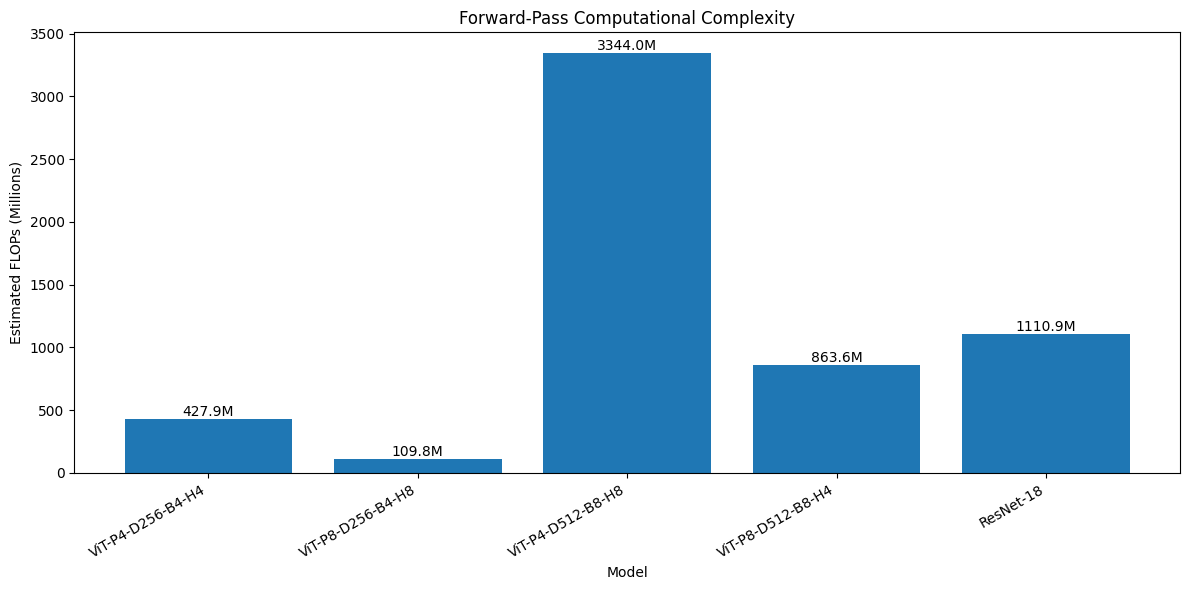

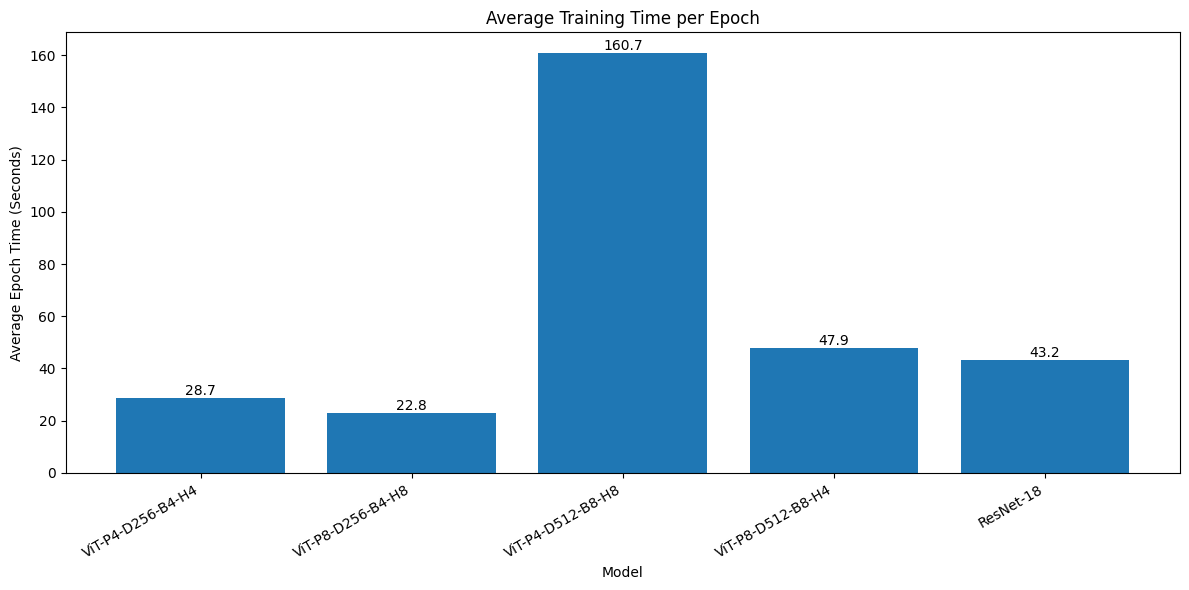

In [ ]:
results_dataframe = pd.DataFrame(results)

report_table = results_dataframe[
    [
        "Model",
        "Patch Size",
        "Embedding Dimension",
        "Blocks",
        "Heads",
        "Actual Parameters",
        "Theoretical Parameters",
        "Estimated FLOPs",
        "Best Validation Accuracy (%)",
        "Test Accuracy (%)",
        "Average Epoch Time (sec)",
        "Total Training Time (sec)"
    ]
].copy()

report_table["Actual Parameters (Millions)"] = (report_table["Actual Parameters"] / 1e6)

report_table["Theoretical Parameters (Millions)"] = (report_table["Theoretical Parameters"] / 1e6)

report_table["Estimated FLOPs (Millions)"] = (report_table["Estimated FLOPs"] / 1e6)

report_table = report_table.drop(
    columns=[
        "Actual Parameters",
        "Theoretical Parameters",
        "Estimated FLOPs"
    ]
)

columns_to_round = [
    "Actual Parameters (Millions)",
    "Theoretical Parameters (Millions)",
    "Estimated FLOPs (Millions)",
    "Best Validation Accuracy (%)",
    "Test Accuracy (%)",
    "Average Epoch Time (sec)",
    "Total Training Time (sec)"
]

report_table[columns_to_round] = report_table[columns_to_round].round(3)

display(report_table)

report_table.to_csv("problem1_results.csv", index=False)

#Training Loss
plt.figure(figsize=(12, 7))

for model_name, history in histories.items():
    epoch_numbers = range(1, len(history["training_loss"]) + 1)

    plt.plot(
        epoch_numbers,
        history["training_loss"],
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss by Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#Validation Accuracy
plt.figure(figsize=(12, 7))

for model_name, history in histories.items():
    epoch_numbers = range(1, len(history["validation_accuracy"]) + 1)

    plt.plot(
        epoch_numbers,
        history["validation_accuracy"],
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy by Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#CIFAR Test Accuracy
plt.figure(figsize=(12, 6))

bars = plt.bar(
    results_dataframe["Model"],
    results_dataframe[
        "Test Accuracy (%)"
    ]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("CIFAR-100 Test Accuracy")
plt.xticks(rotation=30,ha="right")

for bar, value in zip(bars, results_dataframe["Test Accuracy (%)"]
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#Paramter Comparison
parameter_values = (results_dataframe["Actual Parameters"] / 1e6)

plt.figure(figsize=(12, 6))

bars = plt.bar(results_dataframe["Model"], parameter_values)

plt.xlabel("Model")
plt.ylabel("Parameters (Millions)")
plt.title("Model Parameter Comparison")
plt.xticks(rotation=30, ha="right")

for bar, value in zip(bars, parameter_values):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#Estimated Flops
flop_values = (results_dataframe["Estimated FLOPs"] / 1e6)

plt.figure(figsize=(12, 6))

bars = plt.bar(results_dataframe["Model"], flop_values)

plt.xlabel("Model")
plt.ylabel("Estimated FLOPs (Millions)")
plt.title("Forward-Pass Computational Complexity")
plt.xticks(rotation=30,ha="right")

for bar, value in zip(bars, flop_values):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#Average Epoch Time
plt.figure(figsize=(12, 6))

bars = plt.bar(
    results_dataframe["Model"],
    results_dataframe["Average Epoch Time (sec)"])

plt.xlabel("Model")
plt.ylabel("Average Epoch Time (Seconds)")
plt.title("Average Training Time per Epoch")
plt.xticks(rotation=30, ha="right")

for bar, value in zip(bars, results_dataframe["Average Epoch Time (sec)"]):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

##Problem 2:

Import:

In [6]:
!pip install -q transformers
from transformers import AutoImageProcessor
from transformers import SwinConfig
from transformers import SwinForImageClassification

SWIN_BATCH_SIZE = 32
SWIN_EPOCHS = 5
PRETRAINED_LEARNING_RATE = 2e-5
SCRATCH_LEARNING_RATE = 0.001
SWIN_IMAGE_SIZE = 224

SWIN_TINY_CHECKPOINT = "microsoft/swin-tiny-patch4-window7-224"
SWIN_SMALL_CHECKPOINT = "microsoft/swin-small-patch4-window7-224"

swin_processor = AutoImageProcessor.from_pretrained(SWIN_TINY_CHECKPOINT)

SWIN_MEAN = swin_processor.image_mean
SWIN_STD = swin_processor.image_std

print("Device:", DEVICE)
print("Image size:", SWIN_IMAGE_SIZE)
print("Batch size:", SWIN_BATCH_SIZE)
print("Epochs:", SWIN_EPOCHS)
print("Normalization mean:", SWIN_MEAN)
print("Normalization standard deviation:", SWIN_STD)

preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Device: cuda
Image size: 224
Batch size: 32
Epochs: 5
Normalization mean: (0.485, 0.456, 0.406)
Normalization standard deviation: (0.229, 0.224, 0.225)


CIFAR Loader:

In [7]:
swin_train_transform = transforms.Compose([
    transforms.Resize((SWIN_IMAGE_SIZE, SWIN_IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=SWIN_MEAN, std=SWIN_STD)
])

swin_evaluation_transform = transforms.Compose([
    transforms.Resize((SWIN_IMAGE_SIZE, SWIN_IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=SWIN_MEAN,std=SWIN_STD)
])

swin_full_train_augmented = torchvision.datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=swin_train_transform
)

swin_full_train_evaluation = torchvision.datasets.CIFAR100(
    root="./data",
    train=True,
    download=False,
    transform=swin_evaluation_transform
)

swin_test_dataset = torchvision.datasets.CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=swin_evaluation_transform
)

swin_train_dataset = Subset(
    swin_full_train_augmented,
    train_indices
)

swin_validation_dataset = Subset(
    swin_full_train_evaluation,
    validation_indices
)

swin_train_loader = DataLoader(
    swin_train_dataset,
    batch_size=SWIN_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

swin_validation_loader = DataLoader(
    swin_validation_dataset,
    batch_size=SWIN_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

swin_test_loader = DataLoader(
    swin_test_dataset,
    batch_size=SWIN_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Training samples:", len(swin_train_dataset))
print("Validation samples:", len(swin_validation_dataset))
print("Test samples:", len(swin_test_dataset))
print("Number of classes:", len(swin_full_train_augmented.classes))

Training samples: 45000
Validation samples: 5000
Test samples: 10000
Number of classes: 100


Scratch models:

In [8]:
id2label = {
    index: class_name
    for index, class_name
    in enumerate(swin_full_train_augmented.classes)
}

label2id = {
    class_name: index
    for index, class_name
    in enumerate(swin_full_train_augmented.classes)
}


def create_swin_tiny_pretrained():
    model = SwinForImageClassification.from_pretrained(SWIN_TINY_CHECKPOINT, num_labels=NUM_CLASSES, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True)

    for parameter in model.swin.parameters():
        parameter.requires_grad = False

    for parameter in model.classifier.parameters():
        parameter.requires_grad = True

    return model


def create_swin_small_pretrained():
    model = SwinForImageClassification.from_pretrained(
        SWIN_SMALL_CHECKPOINT,
        num_labels=NUM_CLASSES,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    for parameter in model.swin.parameters():
        parameter.requires_grad = False

    for parameter in model.classifier.parameters():
        parameter.requires_grad = True

    return model


def create_swin_tiny_scratch():
    scratch_config = SwinConfig(
        image_size=224,
        patch_size=4,
        num_channels=3,
        num_labels=NUM_CLASSES,
        embed_dim=96,
        depths=[2, 2, 6, 2],
        num_heads=[3, 6, 12, 24],
        window_size=7,
        mlp_ratio=4.0,
        qkv_bias=True,
        hidden_dropout_prob=0.0,
        attention_probs_dropout_prob=0.0,
        drop_path_rate=0.1,
        id2label=id2label,
        label2id=label2id
    )

    model = SwinForImageClassification(scratch_config)

    return model

Paramter Counts:

In [9]:
def count_total_parameters(model):
    return sum(parameter.numel()
        for parameter in model.parameters()
    )


def count_trainable_parameters(model):
    return sum(parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

Evaluation & Training:

In [10]:
def evaluate_swin(model, data_loader,criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(DEVICE, non_blocking=True)

            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(pixel_values=images)

            logits = outputs.logits

            loss = criterion(logits, labels)

            batch_size = labels.size(0)

            total_loss += (loss.item() * batch_size)

            total_correct += (logits.argmax(dim=1) == labels).sum().item()

            total_samples += batch_size

    average_loss = (total_loss / total_samples)

    accuracy = (100 * total_correct / total_samples)

    return average_loss, accuracy

def train_swin_model(
    model,
    model_name,
    learning_rate,
    frozen_backbone
):
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        filter(lambda parameter: parameter.requires_grad, model.parameters()),
        lr=learning_rate
    )

    history = {
        "training_loss": [],
        "training_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": [],
        "epoch_time": []
    }

    best_validation_accuracy = 0.0
    best_model_state = None

    total_start_time = time.perf_counter()

    for epoch in range(SWIN_EPOCHS):
        model.train()

        if frozen_backbone:
            model.swin.eval()
            model.classifier.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        epoch_start_time = time.perf_counter()

        for images, labels in swin_train_loader:
            images = images.to(DEVICE, non_blocking=True)

            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            outputs = model(pixel_values=images)

            logits = outputs.logits

            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)

            total_loss += (loss.item() * batch_size)

            total_correct += (logits.argmax(dim=1) == labels).sum().item()

            total_samples += batch_size

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        epoch_time = (time.perf_counter()- epoch_start_time)

        training_loss = (total_loss / total_samples)

        training_accuracy = (100 * total_correct / total_samples)

        validation_loss, validation_accuracy = evaluate_swin(model, swin_validation_loader, criterion)

        history["training_loss"].append(training_loss)

        history["training_accuracy"].append(training_accuracy)

        history["validation_loss"].append(validation_loss)

        history["validation_accuracy"].append(validation_accuracy)

        history["epoch_time"].append(epoch_time)

        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy

            best_model_state = {
                name: parameter.detach().cpu().clone()
                for name, parameter
                in model.state_dict().items()
            }

        print(
            f"{model_name} | "
            f"Epoch {epoch + 1}/{SWIN_EPOCHS} | "
            f"Train Loss: {training_loss:.4f} | "
            f"Train Acc: {training_accuracy:.2f}% | "
            f"Val Loss: {validation_loss:.4f} | "
            f"Val Acc: {validation_accuracy:.2f}% | "
            f"Time: {epoch_time:.2f} sec"
        )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    total_training_time = (time.perf_counter()- total_start_time)

    if best_model_state is not None:model.load_state_dict(best_model_state)

    test_loss, test_accuracy = evaluate_swin(model, swin_test_loader, criterion)

    average_epoch_time = float(np.mean(history["epoch_time"]))

    print("-" * 80)

    print(f"{model_name} best validation accuracy: "f"{best_validation_accuracy:.2f}%")

    print(f"{model_name} test accuracy: "f"{test_accuracy:.2f}%")

    print(f"{model_name} average epoch time: "f"{average_epoch_time:.2f} seconds")

    print("-" * 80)

    return {
        "model": model,
        "history": history,
        "best_validation_accuracy": best_validation_accuracy,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "average_epoch_time": average_epoch_time,
        "total_training_time": total_training_time
    }

Pre-Trained Models:

In [11]:
problem2_results = []
problem2_histories = {}


##Pre-Trained Swin-Tiny
swin_tiny_pretrained = create_swin_tiny_pretrained()

tiny_total_parameters = count_total_parameters(swin_tiny_pretrained)

tiny_trainable_parameters = count_trainable_parameters(swin_tiny_pretrained)

print("Total parameters:", tiny_total_parameters)
print("Trainable parameters:", tiny_trainable_parameters)

tiny_output = train_swin_model(
    model=swin_tiny_pretrained,
    model_name="Swin-Tiny Pretrained",
    learning_rate=PRETRAINED_LEARNING_RATE,
    frozen_backbone=True
)

problem2_results.append({
    "Model": "Swin-Tiny Pretrained",
    "Initialization": "ImageNet Pretrained",
    "Backbone": "Frozen",
    "Learning Rate": PRETRAINED_LEARNING_RATE,
    "Batch Size": SWIN_BATCH_SIZE,
    "Epochs": SWIN_EPOCHS,
    "Total Parameters": tiny_total_parameters,
    "Trainable Parameters": tiny_trainable_parameters,
    "Best Validation Accuracy (%)": tiny_output[
        "best_validation_accuracy"
    ],
    "Test Accuracy (%)": tiny_output[
        "test_accuracy"
    ],
    "Test Loss": tiny_output[
        "test_loss"
    ],
    "Average Epoch Time (sec)": tiny_output[
        "average_epoch_time"
    ],
    "Total Training Time (sec)": tiny_output[
        "total_training_time"
    ]
})

problem2_histories["Swin-Tiny Pretrained"] = (tiny_output["history"])

tiny_output["model"].to("cpu")

del swin_tiny_pretrained
del tiny_output

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  113MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Total parameters: 27596254
Trainable parameters: 76900
Swin-Tiny Pretrained | Epoch 1/5 | Train Loss: 4.1106 | Train Acc: 21.74% | Val Loss: 3.5902 | Val Acc: 45.04% | Time: 205.68 sec
Swin-Tiny Pretrained | Epoch 2/5 | Train Loss: 3.1580 | Train Acc: 53.29% | Val Loss: 2.7828 | Val Acc: 57.84% | Time: 206.03 sec
Swin-Tiny Pretrained | Epoch 3/5 | Train Loss: 2.4805 | Train Acc: 60.98% | Val Loss: 2.2311 | Val Acc: 62.42% | Time: 205.90 sec
Swin-Tiny Pretrained | Epoch 4/5 | Train Loss: 2.0289 | Train Acc: 64.34% | Val Loss: 1.8723 | Val Acc: 64.82% | Time: 205.78 sec
Swin-Tiny Pretrained | Epoch 5/5 | Train Loss: 1.7355 | Train Acc: 66.52% | Val Loss: 1.6381 | Val Acc: 66.48% | Time: 206.05 sec
--------------------------------------------------------------------------------
Swin-Tiny Pretrained best validation accuracy: 66.48%
Swin-Tiny Pretrained test accuracy: 65.96%
Swin-Tiny Pretrained average epoch time: 205.89 seconds
-------------------------------------------------------------

In [12]:
##Pre-Trained Swin-Small
swin_small_pretrained = create_swin_small_pretrained()

small_total_parameters = count_total_parameters(swin_small_pretrained)

small_trainable_parameters = count_trainable_parameters(swin_small_pretrained)

print("Total parameters:", small_total_parameters)
print("Trainable parameters:", small_trainable_parameters)

small_output = train_swin_model(model=swin_small_pretrained, model_name="Swin-Small Pretrained", learning_rate=PRETRAINED_LEARNING_RATE, frozen_backbone=True)

problem2_results.append({
    "Model": "Swin-Small Pretrained",
    "Initialization": "ImageNet Pretrained",
    "Backbone": "Frozen",
    "Learning Rate": PRETRAINED_LEARNING_RATE,
    "Batch Size": SWIN_BATCH_SIZE,
    "Epochs": SWIN_EPOCHS,
    "Total Parameters": small_total_parameters,
    "Trainable Parameters": small_trainable_parameters,
    "Best Validation Accuracy (%)": small_output[
        "best_validation_accuracy"
    ],
    "Test Accuracy (%)": small_output[
        "test_accuracy"
    ],
    "Test Loss": small_output[
        "test_loss"
    ],
    "Average Epoch Time (sec)": small_output[
        "average_epoch_time"
    ],
    "Total Training Time (sec)": small_output[
        "total_training_time"
    ]
})

problem2_histories["Swin-Small Pretrained"] = (small_output["history"])

small_output["model"].to("cpu")

del swin_small_pretrained
del small_output

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  199MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/425 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-small-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Total parameters: 48914158
Trainable parameters: 76900


model.safetensors: reconstructing file:   0%|          |  0.00B /  199MB            

model.safetensors: downloading bytes:           |  0.00B            

Swin-Small Pretrained | Epoch 1/5 | Train Loss: 4.0408 | Train Acc: 26.11% | Val Loss: 3.4784 | Val Acc: 50.30% | Time: 369.62 sec
Swin-Small Pretrained | Epoch 2/5 | Train Loss: 3.0082 | Train Acc: 58.18% | Val Loss: 2.6130 | Val Acc: 62.20% | Time: 368.58 sec
Swin-Small Pretrained | Epoch 3/5 | Train Loss: 2.2879 | Train Acc: 64.76% | Val Loss: 2.0404 | Val Acc: 65.88% | Time: 368.65 sec
Swin-Small Pretrained | Epoch 4/5 | Train Loss: 1.8283 | Train Acc: 67.69% | Val Loss: 1.6881 | Val Acc: 67.72% | Time: 368.28 sec
Swin-Small Pretrained | Epoch 5/5 | Train Loss: 1.5443 | Train Acc: 69.31% | Val Loss: 1.4680 | Val Acc: 69.20% | Time: 366.71 sec
--------------------------------------------------------------------------------
Swin-Small Pretrained best validation accuracy: 69.20%
Swin-Small Pretrained test accuracy: 69.97%
Swin-Small Pretrained average epoch time: 368.37 seconds
--------------------------------------------------------------------------------


In [13]:
##Train Swim-Tiny
swin_tiny_scratch = create_swin_tiny_scratch()

scratch_total_parameters = count_total_parameters(swin_tiny_scratch)

scratch_trainable_parameters = count_trainable_parameters(swin_tiny_scratch)

print("Total parameters:", scratch_total_parameters)
print("Trainable parameters:", scratch_trainable_parameters)

scratch_output = train_swin_model(
    model=swin_tiny_scratch,
    model_name="Swin-Tiny Scratch",
    learning_rate=SCRATCH_LEARNING_RATE,
    frozen_backbone=False
)

problem2_results.append({
    "Model": "Swin-Tiny Scratch",
    "Initialization": "Random",
    "Backbone": "Trainable",
    "Learning Rate": SCRATCH_LEARNING_RATE,
    "Batch Size": SWIN_BATCH_SIZE,
    "Epochs": SWIN_EPOCHS,
    "Total Parameters": scratch_total_parameters,
    "Trainable Parameters": scratch_trainable_parameters,
    "Best Validation Accuracy (%)": scratch_output[
        "best_validation_accuracy"
    ],
    "Test Accuracy (%)": scratch_output[
        "test_accuracy"
    ],
    "Test Loss": scratch_output[
        "test_loss"
    ],
    "Average Epoch Time (sec)": scratch_output[
        "average_epoch_time"
    ],
    "Total Training Time (sec)": scratch_output[
        "total_training_time"
    ]
})

problem2_histories["Swin-Tiny Scratch"] = (scratch_output["history"])

scratch_output["model"].to("cpu")

del swin_tiny_scratch
del scratch_output

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print("Completed experiments:", len(problem2_results))
print("Stored histories:", list(problem2_histories.keys()))

Total parameters: 27596254
Trainable parameters: 27596254
Swin-Tiny Scratch | Epoch 1/5 | Train Loss: 4.6675 | Train Acc: 1.13% | Val Loss: 4.6445 | Val Acc: 1.00% | Time: 587.73 sec
Swin-Tiny Scratch | Epoch 2/5 | Train Loss: 4.6245 | Train Acc: 0.98% | Val Loss: 4.6179 | Val Acc: 1.20% | Time: 585.01 sec
Swin-Tiny Scratch | Epoch 3/5 | Train Loss: 4.6153 | Train Acc: 1.06% | Val Loss: 4.6105 | Val Acc: 1.06% | Time: 582.80 sec
Swin-Tiny Scratch | Epoch 4/5 | Train Loss: 4.6117 | Train Acc: 0.98% | Val Loss: 4.6069 | Val Acc: 1.02% | Time: 583.87 sec
Swin-Tiny Scratch | Epoch 5/5 | Train Loss: 4.6101 | Train Acc: 0.98% | Val Loss: 4.6097 | Val Acc: 0.74% | Time: 583.78 sec
--------------------------------------------------------------------------------
Swin-Tiny Scratch best validation accuracy: 1.20%
Swin-Tiny Scratch test accuracy: 1.00%
Swin-Tiny Scratch average epoch time: 584.64 seconds
--------------------------------------------------------------------------------
Completed exp

Results:

,Model,Initialization,Backbone,Learning Rate,Best Validation Accuracy (%),Test Accuracy (%),Average Epoch Time (sec),Total Training Time (sec),Total Parameters (Millions),Trainable Parameters (Millions)
0,Swin-Tiny Pretrained,ImageNet Pretrained,Frozen,0.00002,66.48,65.96,205.887,1145.376,27.596,0.077
1,Swin-Small Pretrained,ImageNet Pretrained,Frozen,0.00002,69.20,69.97,368.368,2048.108,48.914,0.077
2,Swin-Tiny Scratch,Random,Trainable,0.00100,1.20,1.00,584.641,3035.490,27.596,27.596


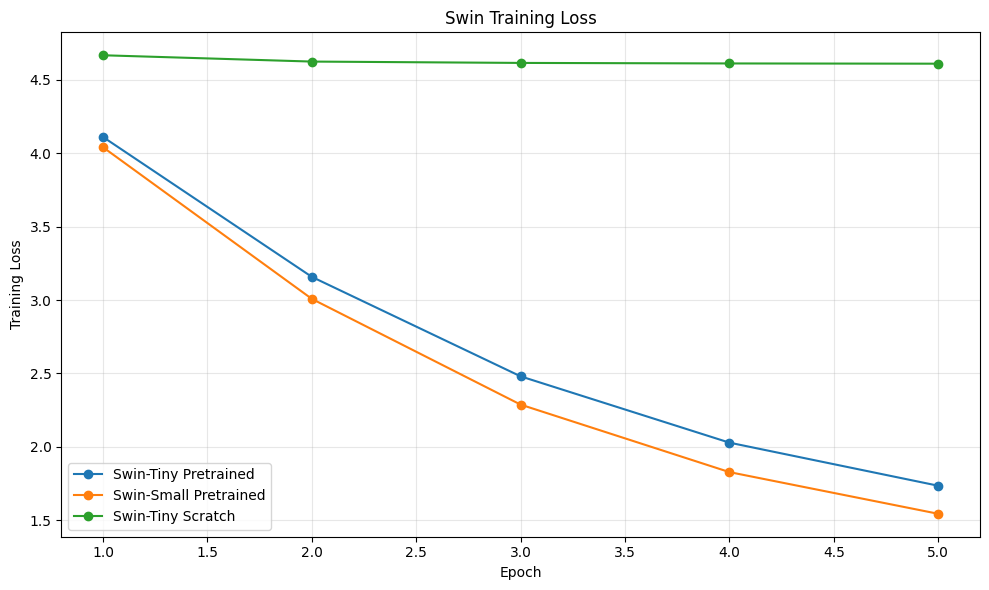

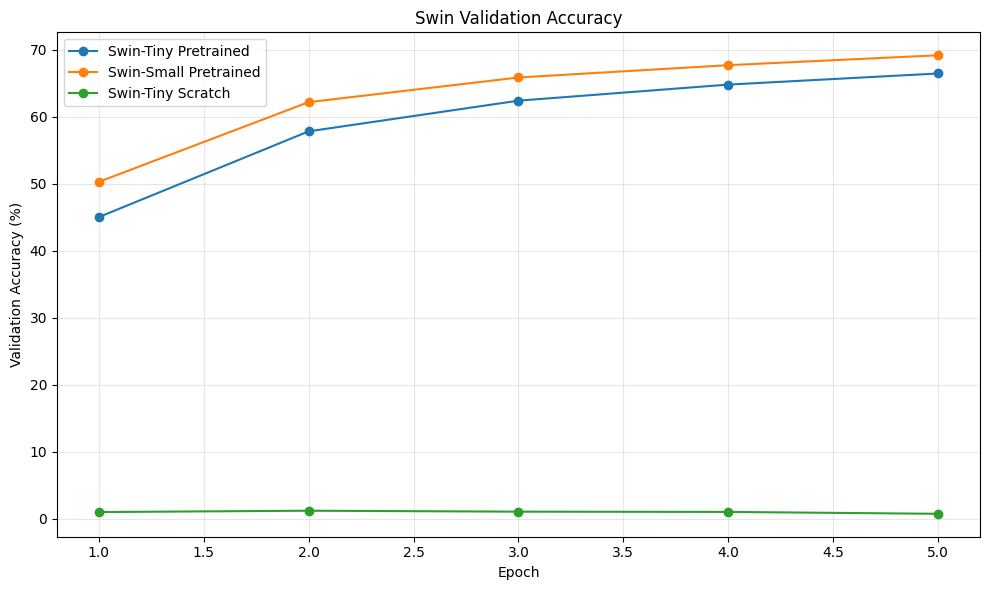

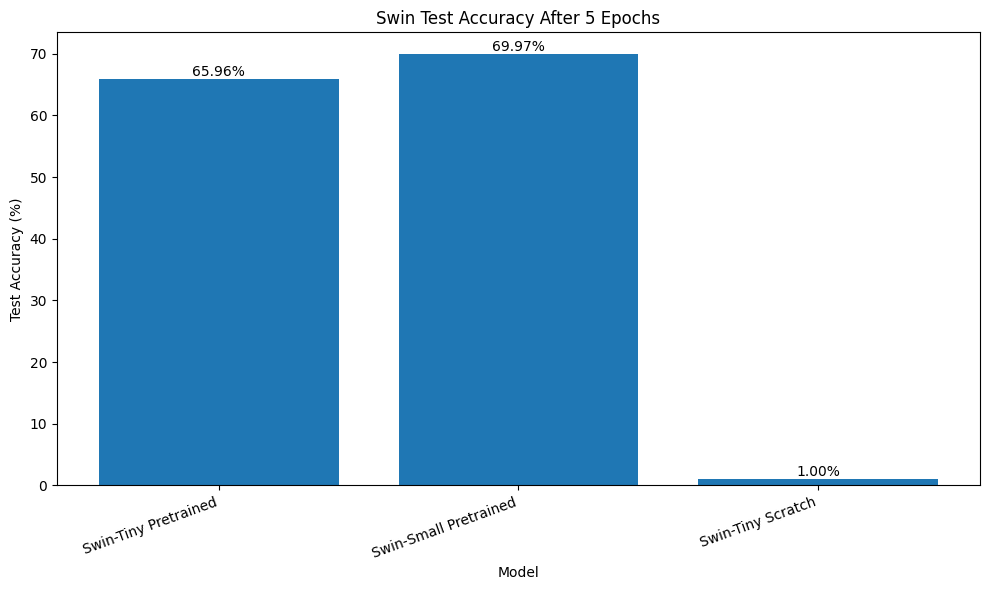

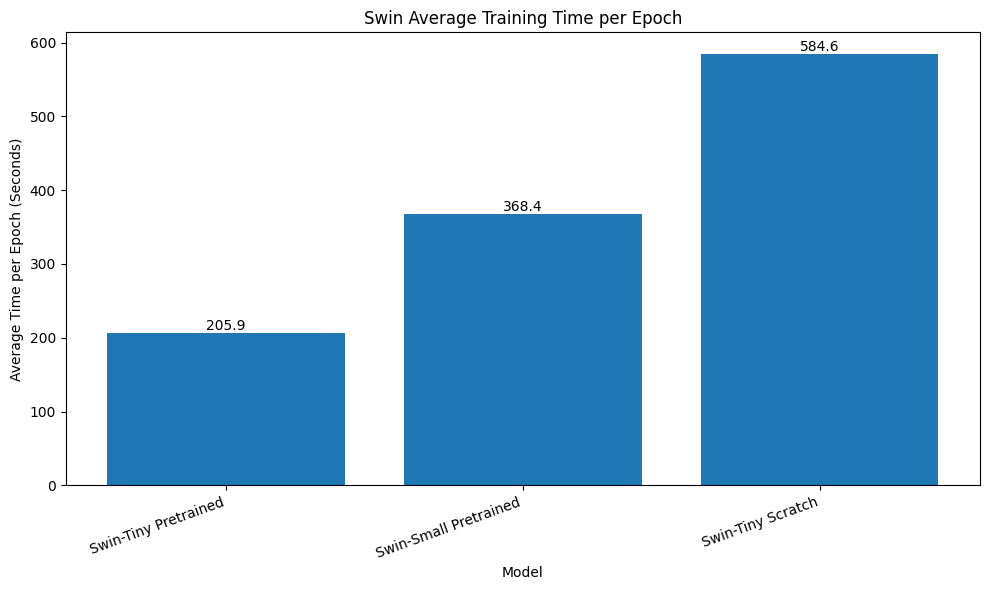

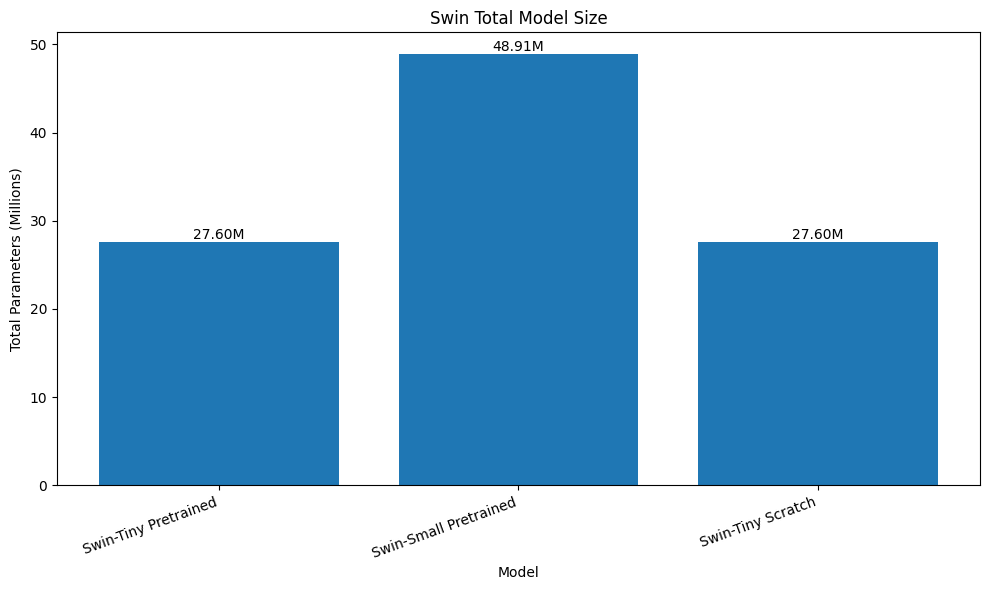

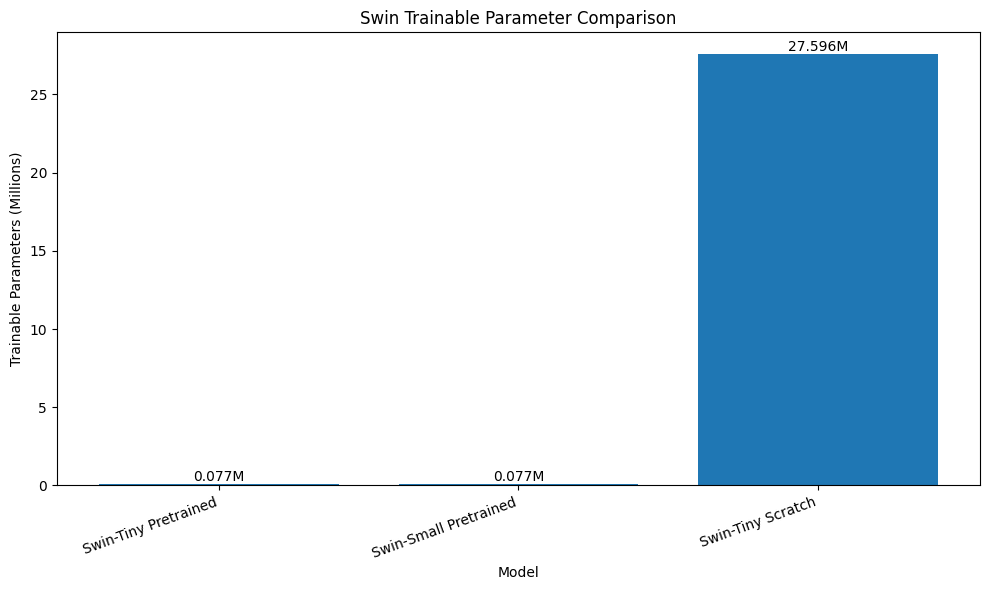

In [14]:
problem2_dataframe = pd.DataFrame(problem2_results)

problem2_report_table = problem2_dataframe[
    [
        "Model",
        "Initialization",
        "Backbone",
        "Learning Rate",
        "Total Parameters",
        "Trainable Parameters",
        "Best Validation Accuracy (%)",
        "Test Accuracy (%)",
        "Average Epoch Time (sec)",
        "Total Training Time (sec)"
    ]
].copy()

problem2_report_table["Total Parameters (Millions)"] = (problem2_report_table["Total Parameters"] / 1e6)

problem2_report_table["Trainable Parameters (Millions)"] = (problem2_report_table["Trainable Parameters"] / 1e6)

problem2_report_table = problem2_report_table.drop(columns=["Total Parameters", "Trainable Parameters"])

columns_to_round = [
    "Total Parameters (Millions)",
    "Trainable Parameters (Millions)",
    "Best Validation Accuracy (%)",
    "Test Accuracy (%)",
    "Average Epoch Time (sec)",
    "Total Training Time (sec)"
]

problem2_report_table[columns_to_round] = problem2_report_table[columns_to_round].round(3)

display(problem2_report_table)

problem2_report_table.to_csv(
    "problem2_swin_results.csv",
    index=False
)

##Training Loss
plt.figure(figsize=(10, 6))

for model_name, history in problem2_histories.items():
    epoch_numbers = range(1, len(history["training_loss"]) + 1)

    plt.plot(epoch_numbers,history["training_loss"],marker="o",label=model_name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Swin Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##Validation Accuracy
plt.figure(figsize=(10, 6))

for model_name, history in problem2_histories.items():
    epoch_numbers = range(1, len(history["validation_accuracy"]) + 1)

    plt.plot(epoch_numbers, history["validation_accuracy"], marker="o", label=model_name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Swin Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##Test Accuracy
plt.figure(figsize=(10, 6))

bars = plt.bar(problem2_dataframe["Model"], problem2_dataframe["Test Accuracy (%)"])

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Swin Test Accuracy After 5 Epochs")
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, problem2_dataframe["Test Accuracy (%)"]):
    plt.text(bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

##Epoch Time
plt.figure(figsize=(10, 6))

bars = plt.bar(problem2_dataframe["Model"], problem2_dataframe["Average Epoch Time (sec)"])

plt.xlabel("Model")
plt.ylabel("Average Time per Epoch (Seconds)")
plt.title("Swin Average Training Time per Epoch")
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, problem2_dataframe["Average Epoch Time (sec)"]
):
    plt.text(bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

##Model Size
total_parameter_values = (problem2_dataframe["Total Parameters"] / 1e6)

plt.figure(figsize=(10, 6))

bars = plt.bar(problem2_dataframe["Model"], total_parameter_values)

plt.xlabel("Model")
plt.ylabel("Total Parameters (Millions)")
plt.title("Swin Total Model Size")
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars,total_parameter_values):
    plt.text(bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

##Trainable Paramters
trainable_parameter_values = (problem2_dataframe["Trainable Parameters"] / 1e6)

plt.figure(figsize=(10, 6))

bars = plt.bar(problem2_dataframe["Model"], trainable_parameter_values)

plt.xlabel("Model")
plt.ylabel("Trainable Parameters (Millions)")
plt.title("Swin Trainable Parameter Comparison")
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, trainable_parameter_values):
    plt.text(bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()